In [21]:
from order_book import OrderBook
from models import Order, ReqType, Request, Trade
from agents import Agent
from simulation import Simulation
from strategies import Random, NaiveMM
from analytics import Analytics

from collections import deque
from dataclasses import dataclass
from enum import Enum
import matplotlib as plt

In [22]:
sim = Simulation(initial_price=100)
analysis = Analytics(sim)

# create 100 random agents with fixed probabilities
for i in range(1, 11):
    strat = Random(
        buy_probability=0.33,
        sell_probability=0.33,
        cancel_probability=0.2,
        limit_probability=0.8,
        max_quantity=10,
        max_price_offset=10,
        reference_price=sim.initial_price,
    )
    agent = Agent(
        agent_id=i,
        initial_cash=10000,
        initial_position=100,
        strategy=strat
    )
    sim.agents[i] = agent

strat = NaiveMM(
    half_spread=2,
    time_req=2,
    tolerance=2,
    quantity=10
)

sim.agents[11] = Agent(
    agent_id=11,
    initial_cash=10000,
    initial_position=100,
    strategy=strat,
)

In [23]:
sim.run_sim(100000)
len(sim.book.trades)

64871

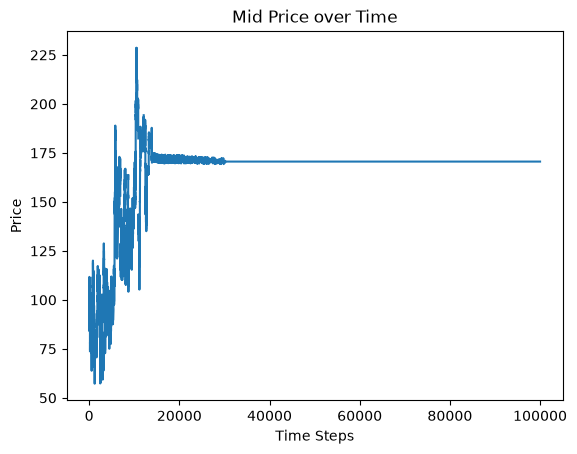

In [24]:
analysis.plot_midprice()

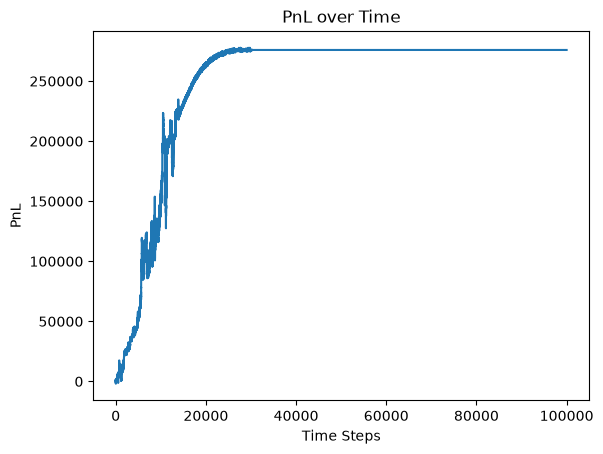

In [25]:
analysis.plot_agent_pnl(11)

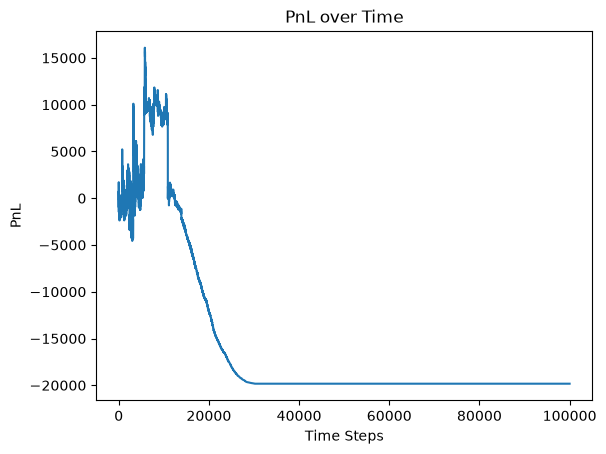

In [26]:
analysis.plot_agent_pnl(1)